In [1]:
### Tienda Online Ice: Patrones de exito en la venta de videojuegos

In [2]:
# Cargar todas las librerías
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import numpy as np
import math as mt
from math import factorial
from scipy import stats as st

In [3]:
# Carga los archivos de datos en diferentes DataFrames
df = pd.read_csv('/datasets/games.csv')

df.head(5)

,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN


In [4]:
# Nombres de columnas en minúscula
df.columns = df.columns.str.lower()
df.columns

Index(['name', 'platform', 'year_of_release', 'genre', 'na_sales', 'eu_sales',
       'jp_sales', 'other_sales', 'critic_score', 'user_score', 'rating'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16713 non-null  object 
 1   platform         16715 non-null  object 
 2   year_of_release  16446 non-null  float64
 3   genre            16713 non-null  object 
 4   na_sales         16715 non-null  float64
 5   eu_sales         16715 non-null  float64
 6   jp_sales         16715 non-null  float64
 7   other_sales      16715 non-null  float64
 8   critic_score     8137 non-null   float64
 9   user_score       10014 non-null  object 
 10  rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB


In [6]:
# Conteo de valores nulos por columna
missing = df.isna().sum().sort_values(ascending=False)
print(missing)

critic_score       8578
rating             6766
user_score         6701
year_of_release     269
name                  2
genre                 2
platform              0
na_sales              0
eu_sales              0
jp_sales              0
other_sales           0
dtype: int64


In [7]:
# Revisando los valores unicos en todo el DataFrame
for col in df.columns:
    print(f"Columna: {col}")
    print(df[col].unique())

Columna: name
['Wii Sports' 'Super Mario Bros.' 'Mario Kart Wii' ...
 'Woody Woodpecker in Crazy Castle 5' 'LMA Manager 2007'
 'Haitaka no Psychedelica']
Columna: platform
['Wii' 'NES' 'GB' 'DS' 'X360' 'PS3' 'PS2' 'SNES' 'GBA' 'PS4' '3DS' 'N64'
 'PS' 'XB' 'PC' '2600' 'PSP' 'XOne' 'WiiU' 'GC' 'GEN' 'DC' 'PSV' 'SAT'
 'SCD' 'WS' 'NG' 'TG16' '3DO' 'GG' 'PCFX']
Columna: year_of_release
[2006. 1985. 2008. 2009. 1996. 1989. 1984. 2005. 1999. 2007. 2010. 2013.
 2004. 1990. 1988. 2002. 2001. 2011. 1998. 2015. 2012. 2014. 1992. 1997.
 1993. 1994. 1982. 2016. 2003. 1986. 2000.   nan 1995. 1991. 1981. 1987.
 1980. 1983.]
Columna: genre
['Sports' 'Platform' 'Racing' 'Role-Playing' 'Puzzle' 'Misc' 'Shooter'
 'Simulation' 'Action' 'Fighting' 'Adventure' 'Strategy' nan]
Columna: na_sales
[4.136e+01 2.908e+01 1.568e+01 1.561e+01 1.127e+01 2.320e+01 1.128e+01
 1.396e+01 1.444e+01 2.693e+01 9.050e+00 9.710e+00 9.000e+00 8.920e+00
 1.500e+01 9.010e+00 7.020e+00 9.430e+00 1.278e+01 4.740e+00 6.380e+00
 1.0

In [8]:
# Debido a que se encuentra 'tbd' en user_score se convierte para ser tratado como NaN
df['user_score'] = df['user_score'].replace({'tbd': np.nan, 'TBD': np.nan})

In [9]:
# Convertir tipos para year_of_release y user_score (los años se expresan como decimales y la calificación de usuario como objeto)
df['year_of_release'] = pd.to_numeric(df['year_of_release'], errors='coerce').astype('Int64')
df['user_score'] = pd.to_numeric(df['user_score'], errors='coerce').astype('float64')

In [10]:
# Reemplazar NaN en year_of_release por 2030 para poder cuantificar
df['year_of_release'] = df['year_of_release'].fillna(2030)
# Reemplazar NaN en name, genre y rating por unknown para poder cuantificar
df['name'] = df['name'].fillna("unknown")
df['genre'] = df['genre'].fillna("unknown")
df['rating'] = df['rating'].fillna("unknown")
# Reemplazar NaN en los scores por los valores medios (aprox. 69 y 7 respectivamente)
print(df['critic_score'].mean())
print(df['user_score'].mean())
df['critic_score'] = df['critic_score'].fillna(69)
df['user_score'] = df['user_score'].fillna(7)

68.96767850559173
7.125046113306982


In [11]:
# Verificando los cambios
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16715 non-null  object 
 1   platform         16715 non-null  object 
 2   year_of_release  16715 non-null  Int64  
 3   genre            16715 non-null  object 
 4   na_sales         16715 non-null  float64
 5   eu_sales         16715 non-null  float64
 6   jp_sales         16715 non-null  float64
 7   other_sales      16715 non-null  float64
 8   critic_score     16715 non-null  float64
 9   user_score       16715 non-null  float64
 10  rating           16715 non-null  object 
dtypes: Int64(1), float64(6), object(4)
memory usage: 1.4+ MB


In [12]:

# Se modificaron los tipos para year_of_release (en decimales por enteros) y user_score (tipo objeto a float).
# Se rellenaron los años para efectos de calculo con el año 2030, los score se quedan con NaN para no sesgar la información.
# Puede ser que algunos productos carecen de calificación porque no se ha añadido de parte de los desarrolladores o porque simplemente no estan sujetos a la misma.
# tbd se manejará como NaN puesto que implica que no tiene calificación al momento de realizado el analisis.
# No se eliminaron filas para evitar perder información de ventas, se utilizó "unknown" y los promedios de calificación en cambio.


In [13]:
# Calcular ventas totales
df['total_sales'] = df[['na_sales','eu_sales','jp_sales','other_sales']].sum(axis=1)

In [14]:
df.head()

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales
0,Wii Sports,Wii,2006,Sports,41.36,28.96,3.77,8.45,76.0,8.0,E,82.54
1,Super Mario Bros.,NES,1985,Platform,29.08,3.58,6.81,0.77,69.0,7.0,unknown,40.24
2,Mario Kart Wii,Wii,2008,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E,35.52
3,Wii Sports Resort,Wii,2009,Sports,15.61,10.93,3.28,2.95,80.0,8.0,E,32.77
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,11.27,8.89,10.22,1.00,69.0,7.0,unknown,31.38


In [15]:
## Analizando los datos

In [16]:
# Conteo de juegos por año
releases = df.groupby('year_of_release').size().reset_index(name='count').sort_values('year_of_release')
print(releases)

    year_of_release  count
0              1980      9
1              1981     46
2              1982     36
3              1983     17
4              1984     14
5              1985     14
6              1986     21
7              1987     16
8              1988     15
9              1989     17
10             1990     16
11             1991     41
12             1992     43
13             1993     62
14             1994    121
15             1995    219
16             1996    263
17             1997    289
18             1998    379
19             1999    338
20             2000    350
21             2001    482
22             2002    829
23             2003    775
24             2004    762
25             2005    939
26             2006   1006
27             2007   1197
28             2008   1427
29             2009   1426
30             2010   1255
31             2011   1136
32             2012    653
33             2013    544
34             2014    581
35             2015    606
3

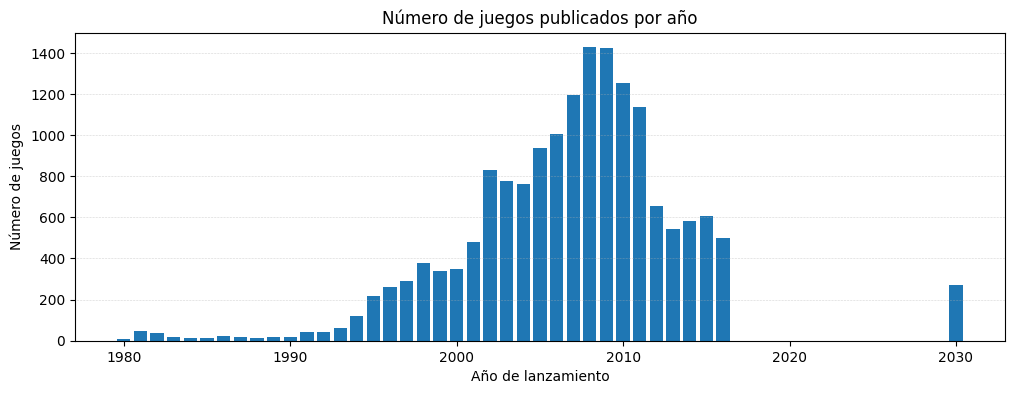

In [17]:
# gráfico de barras: año de lanzamiento vs. número de juegos
plt.figure(figsize=(12,4))
plt.bar(releases['year_of_release'].astype(float), releases['count'])
plt.xlabel('Año de lanzamiento')
plt.ylabel('Número de juegos')
plt.title('Número de juegos publicados por año')
plt.grid(axis='y', linestyle=':', linewidth=0.4)
plt.show()

In [18]:

# Por el gráfico de barras realizado se puede observar una tendencia de crecimiento en los años posteriores al 2010, alcanzando el punto más alto entre 2008 y 2009.
# Posterior al 2009 se ve un decrecimiento pronunciado entre 2011 y 2012, sin embargo se mantiene estable hasta 2016.
# Año 2030 para representar los datos que no especifican año de lanzamiento.


In [19]:

# ventas totales por plataforma (histórico)
platform_sales = df.groupby('platform')['total_sales'].sum().sort_values(ascending=False).reset_index()
print(platform_sales)
print()


# seleccionar top plataformas y ver su evolución anual

top_platforms = platform_sales['platform'].head(5).tolist()
pivot = df[df['platform'].isin(top_platforms)].pivot_table(
    index='year_of_release', columns='platform', values='total_sales', aggfunc='sum').fillna(0)
print(pivot)

   platform  total_sales
0       PS2      1255.77
1      X360       971.42
2       PS3       939.65
3       Wii       907.51
4        DS       806.12
5        PS       730.86
6       GBA       317.85
7       PS4       314.14
8       PSP       294.05
9        PC       259.52
10      3DS       259.00
11       XB       257.74
12       GB       255.46
13      NES       251.05
14      N64       218.68
15     SNES       200.04
16       GC       198.93
17     XOne       159.32
18     2600        96.98
19     WiiU        82.19
20      PSV        54.07
21      SAT        33.59
22      GEN        30.77
23       DC        15.95
24      SCD         1.86
25       NG         1.44
26       WS         1.42
27     TG16         0.16
28      3DO         0.10
29       GG         0.04
30     PCFX         0.03

platform             DS     PS2     PS3     Wii    X360
year_of_release                                        
1985               0.02    0.00    0.00    0.00    0.00
2000               0.00   39.17

    year  count
0   1980      9
1   1981     46
2   1982     36
3   1983     17
4   1984     14
5   1985     14
6   1986     21
7   1987     16
8   1988     15
9   1989     17
10  1990     16
11  1991     41
12  1992     43
13  1993     62
14  1994    121
15  1995    219
16  1996    263
17  1997    289
18  1998    379
19  1999    338
20  2000    350
21  2001    482
22  2002    829
23  2003    775
24  2004    762
25  2005    939
26  2006   1006
27  2007   1197
28  2008   1427
29  2009   1426
30  2010   1255
31  2011   1136
32  2012    653
33  2013    544
34  2014    581
35  2015    606
36  2016    502
37  2030    269


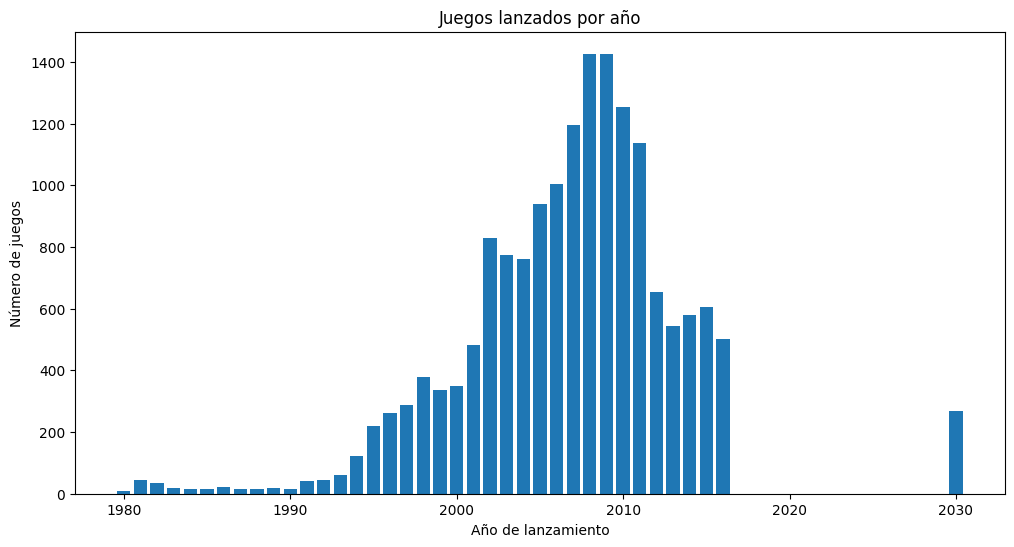

In [20]:
# Número de juegos lanzados por año
games_per_year = df.groupby("year_of_release")["name"].count().reset_index()
games_per_year.columns = ["year", "count"]

print(games_per_year)

# Gráfico para visualizar
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.bar(games_per_year["year"], games_per_year["count"])
plt.xlabel("Año de lanzamiento")
plt.ylabel("Número de juegos")
plt.title("Juegos lanzados por año")
plt.show()

In [21]:
# Los datos menos representativos se encuentran en la decada de los 80's, entre 2008 y 2009 se lanzó la mayor cantidad de juegos, el periodo más estable en cuanto a lanzamientos es del 2012 al 2016.

platform
PS2     1255.77
X360     971.42
PS3      939.65
Wii      907.51
DS       806.12
PS       730.86
GBA      317.85
PS4      314.14
PSP      294.05
PC       259.52
Name: total_sales, dtype: float64


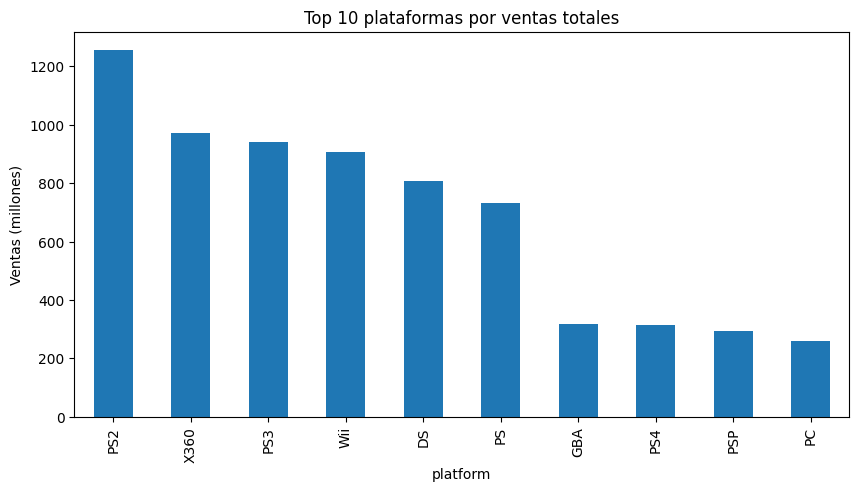

In [22]:
# Ventas acumuladas por plataforma
platform_sales = df.groupby("platform")["total_sales"].sum().sort_values(ascending=False)
print(platform_sales.head(10))

# Gráfico top plataformas
platform_sales.head(10).plot(kind="bar", figsize=(10,5), title="Top 10 plataformas por ventas totales")
plt.ylabel("Ventas (millones)")
plt.show()

In [23]:


# Entre las plataformas más populares se encuentran la PS2 y 3 de Sony, así como la Wii y la DS de Nintendo, a pesar de estar descontinuadas.
# Se pone en evidencia la transición de generaciones de consolas, de PS2 a la 3 y finalmente a la 4 que tiene poco tiempo en el mercado y levanto ventas con rapidez.



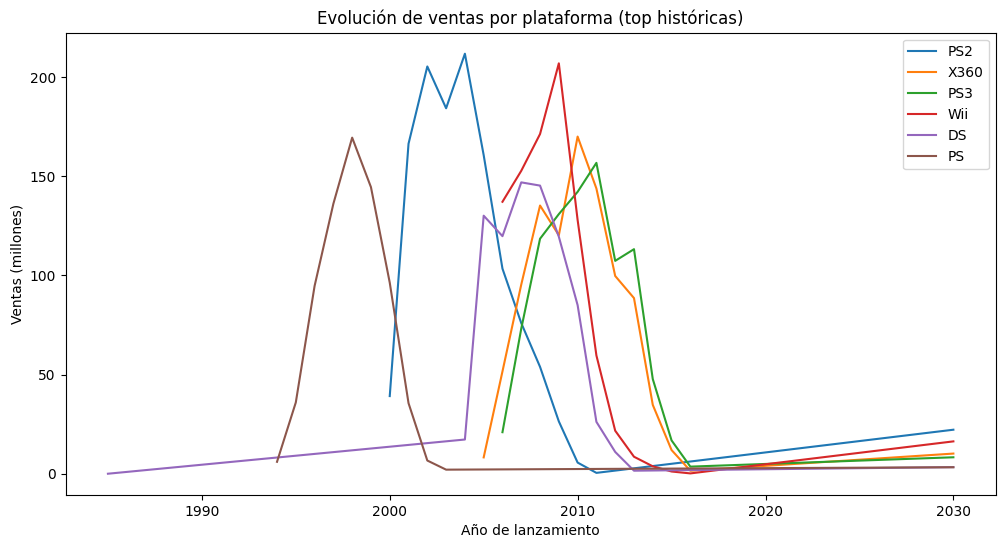

In [24]:
# Seleccionamos las plataformas con más ventas totales
top_platforms = platform_sales.head(6).index

# Evolución anual de ventas para estas plataformas
ventas_año_plataforma = df.groupby(['year_of_release', 'platform'])['total_sales'].sum().reset_index()
ventas_año_top = ventas_año_plataforma[ventas_año_plataforma['platform'].isin(top_platforms)]

plt.figure(figsize=(12,6))
for plataforma in top_platforms:
    data = ventas_año_top[ventas_año_top['platform'] == plataforma]
    plt.plot(data['year_of_release'], data['total_sales'], label=plataforma)

plt.xlabel("Año de lanzamiento")
plt.ylabel("Ventas (millones)")
plt.title("Evolución de ventas por plataforma (top históricas)")
plt.legend()
plt.show()

In [25]:
# Primer y último año de lanzamientos por plataforma
# Excluir año 2030 (año ficticio)
df_filtered = df[df["year_of_release"] != 2030]

# Agrupación y cálculo de span
platform_span = df_filtered.groupby("platform")["year_of_release"].agg(["min", "max"])
platform_span["span_years"] = platform_span["max"] - platform_span["min"]

# Mostrar las 10 plataformas con mayor rango de años
print(platform_span.sort_values("span_years", ascending=False).head(10))

           min   max  span_years
platform                        
PC        1985  2016          31
DS        1985  2013          28
GB        1988  2001          13
X360      2005  2016          11
PSP       2004  2015          11
PS2       2000  2011          11
NES       1983  1994          11
DC        1998  2008          10
Wii       2006  2016          10
PS3       2006  2016          10


In [26]:
# Conteo de juegos recientes (2008–2016)
recent_counts = df[df["year_of_release"] >= 2008].groupby("year_of_release")["name"].count()
print(recent_counts)

# Filtramos periodo final recomendado (ej: 2012–2016)
relevant_df = df[df["year_of_release"] >= 2012].copy()
print("Número de juegos en 2012–2016:", relevant_df.shape[0])

year_of_release
2008    1427
2009    1426
2010    1255
2011    1136
2012     653
2013     544
2014     581
2015     606
2016     502
2030     269
Name: name, dtype: int64
Número de juegos en 2012–2016: 3155


In [27]:

# Las consolas con mayores ventas totales son PS, PS2 y PS3 de Sony, X360 de Microsoft así como Wii y DS de Nintendo.
# El tiempo que toma a las compañias renovar su hardware varía de modelo en modelo, para consolas (no PC) la vida util se acerca a los 11 años en promedio, en el caso de Sony la nueva generación llega despues de 6 años aunque no se descontinua la versión anterior hasta los 11.
# El periodo de tiempo idoneo para modelar los datos se considera entre el 2012 y 2016 puesto que es el más estable considerando la baja de los 80's, el incremento de los 90's hasta llegar al pico de 2008 y 2009 y el declive hasta encontrar cierta estabilidad a partir del 2012.


In [28]:
# Ventas acumuladas antes y después de 2012
past_sales = df[(df["year_of_release"] >= 2000) & (df["year_of_release"] <= 2011)] \
                .groupby("platform")["total_sales"].sum()
recent_sales = df[(df["year_of_release"] >= 2012)] \
                .groupby("platform")["total_sales"].sum()

compare_sales = pd.DataFrame({
    "past_2000_2011": past_sales,
    "recent_2012_2016": recent_sales
}).fillna(0)

compare_sales["change"] = compare_sales["recent_2012_2016"] - compare_sales["past_2000_2011"]
print(compare_sales.sort_values("recent_2012_2016", ascending=False).head(10))

          past_2000_2011  recent_2012_2016   change
platform                                           
PS4                 0.00            314.14   314.14
PS3               642.55            297.10  -345.45
X360              724.70            246.72  -477.98
3DS                63.20            195.80   132.60
XOne                0.00            159.32   159.32
WiiU                0.00             82.19    82.19
PC                143.07             66.41   -76.66
Wii               855.81             51.70  -804.11
PSV                 4.63             49.44    44.81
PS2              1233.56             22.21 -1211.35


In [29]:

# De acuerdo a la comparación realizada entre el periodo anterior al periodo de evaluación se establecen las consolas populares anteriormente que perdieron fuerza para el periodo en evaluación y los potenciales de negocio.
# Plataformas lideres en ventas que se reducen: PS2, PS3, Wii, X360, PC
# Plataformas lideres en ventas que aumentan sus ventas: PS4, 3DS, XOne, PSV (nueva generación)


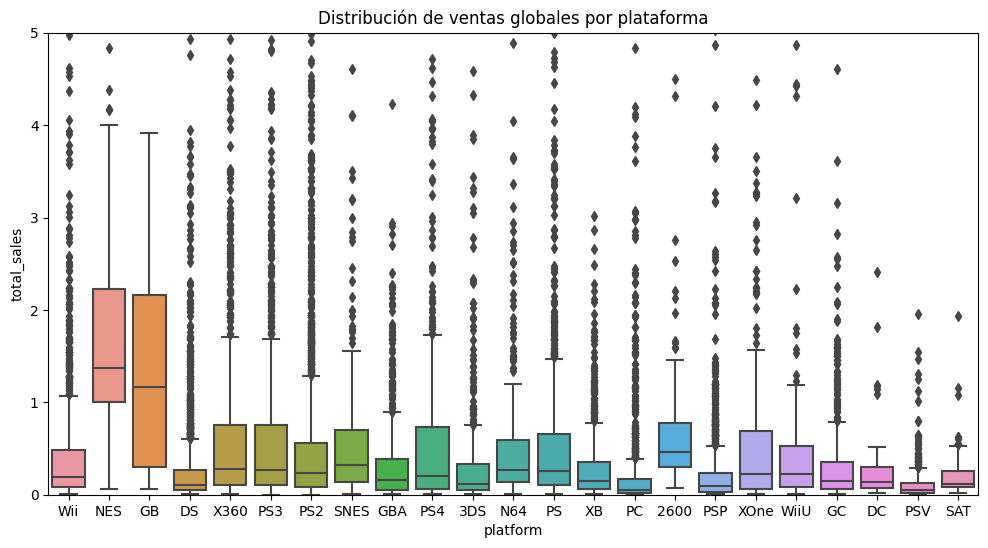

In [30]:
# Seleccionamos plataformas con al menos 50 juegos
platform_counts = df["platform"].value_counts()
popular_platforms = platform_counts[platform_counts >= 50].index

plt.figure(figsize=(12,6))
sns.boxplot(x="platform", y="total_sales", data=df[df["platform"].isin(popular_platforms)])
plt.ylim(0,5)  # limitar eje Y para ver mejor la distribución, ignorando outliers
plt.title("Distribución de ventas globales por plataforma")
plt.show()

In [31]:
# Se observan grandes diferencias en las ventas, la media varía demasiado, posiblemente por la venta de titulos top en algunas consolas que infla algunos promedios.

Correlación crítica: 0.34887240172175027
Correlación usuarios: -0.039153543162937114


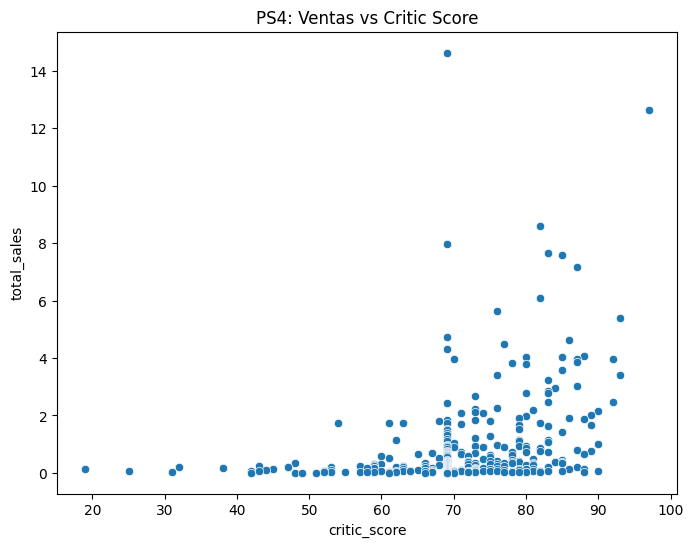

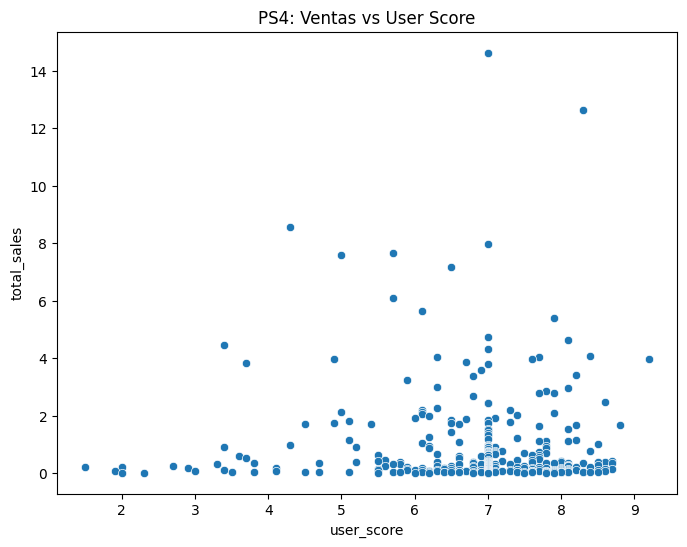

In [32]:
# Filtramos juegos de PS4 (como referencia)
ps4_games = df[df["platform"] == "PS4"]

# Correlaciones
print("Correlación crítica:", ps4_games["critic_score"].corr(ps4_games["total_sales"]))
print("Correlación usuarios:", ps4_games["user_score"].corr(ps4_games["total_sales"]))

# Gráfico critic_score vs ventas
plt.figure(figsize=(8,6))
sns.scatterplot(x="critic_score", y="total_sales", data=ps4_games)
plt.title("PS4: Ventas vs Critic Score")
plt.show()

# Gráfico user_score vs ventas
plt.figure(figsize=(8,6))
sns.scatterplot(x="user_score", y="total_sales", data=ps4_games)
plt.title("PS4: Ventas vs User Score")
plt.show()


In [33]:
# De acuerdo a la correlación establecida entre las calificaciones de criticos y usuarios con las ventas generadas, podemos observar que las opiniones de los criticos afectan de manera moderada las ventas y que, la ponderación de los usuarios pareciera no afectar las ventas en absoluto.

In [34]:
# Identificar juegos con más de una plataforma
multi_games = df.groupby("name")["platform"].nunique()
multi_games = multi_games[multi_games > 1]

# Mostrar algunos ejemplos con sus ventas
sample_multi = df[df["name"].isin(multi_games.index)].head(20)
print(sample_multi[["name", "platform", "total_sales"]])


                              name platform  total_sales
1                Super Mario Bros.      NES        40.24
5                           Tetris       GB        30.26
16              Grand Theft Auto V      PS3        21.05
17   Grand Theft Auto: San Andreas      PS2        20.81
18               Super Mario World     SNES        20.62
22             Super Mario Bros. 3      NES        17.28
23              Grand Theft Auto V     X360        16.27
24     Grand Theft Auto: Vice City      PS2        16.15
29  Call of Duty: Modern Warfare 3     X360        14.73
31       Call of Duty: Black Ops 3      PS4        14.63
32         Call of Duty: Black Ops     X360        14.62
34      Call of Duty: Black Ops II      PS3        13.79
35      Call of Duty: Black Ops II     X360        13.68
36  Call of Duty: Modern Warfare 2     X360        13.47
37  Call of Duty: Modern Warfare 3      PS3        13.33
38            Grand Theft Auto III      PS2        13.10
41         Call of Duty: Black 

Action          3369
Sports          2348
Misc            1750
Role-Playing    1498
Shooter         1323
Adventure       1303
Racing          1249
Platform         888
Simulation       873
Fighting         849
Strategy         683
Puzzle           580
unknown            2
Name: genre, dtype: int64
genre
Action          1744.17
Sports          1331.27
Shooter         1052.45
Role-Playing     934.56
Platform         827.77
Misc             802.51
Racing           728.67
Fighting         447.53
Simulation       389.97
Puzzle           242.57
Adventure        237.59
Strategy         174.23
unknown            2.42
Name: total_sales, dtype: float64
genre
unknown         1.210000
Platform        0.932173
Shooter         0.795503
Role-Playing    0.623872
Racing          0.583403
Sports          0.566980
Fighting        0.527126
Action          0.517711
Misc            0.458577
Simulation      0.446701
Puzzle          0.418224
Strategy        0.255095
Adventure       0.182341
Name: total_sales,

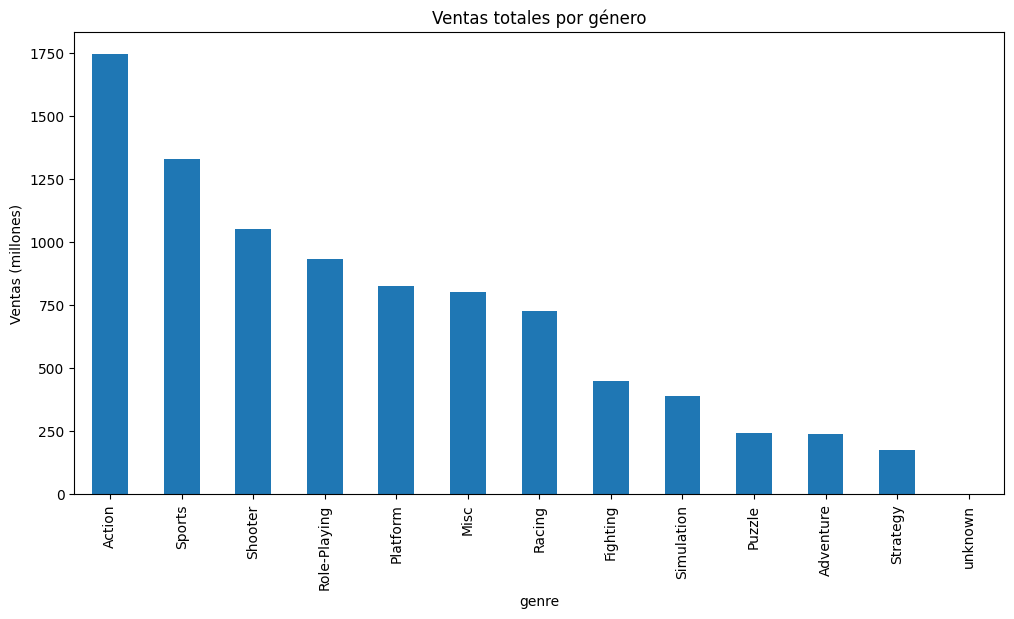

In [35]:
# Conteo de juegos por género
genre_counts = df["genre"].value_counts()
print(genre_counts)

# Ventas totales por género
genre_sales = df.groupby("genre")["total_sales"].sum().sort_values(ascending=False)
print(genre_sales)

# Ventas promedio por juego en cada género
genre_mean_sales = df.groupby("genre")["total_sales"].mean().sort_values(ascending=False)
print(genre_mean_sales)

# Gráfico ventas por género
plt.figure(figsize=(12,6))
genre_sales.plot(kind="bar")
plt.title("Ventas totales por género")
plt.ylabel("Ventas (millones)")
plt.show()


In [36]:

# De acuerdo a la gráfica podemos establecer que los generos de acción, deportes, shooter y RPG son los que generan más ingresos.
# No se puede generalizar acerca de los generos con ventas altas y bajas puesto que se combinan muchos factores (mayor cantidad vendida vs. precio más bajo, menor cantidad vendida vs. precio más alto, etc.)



Top 5 plataformas en NA_SALES:
 platform
X360    602.47
PS2     583.84
Wii     496.90
PS3     393.49
DS      382.40
Name: na_sales, dtype: float64


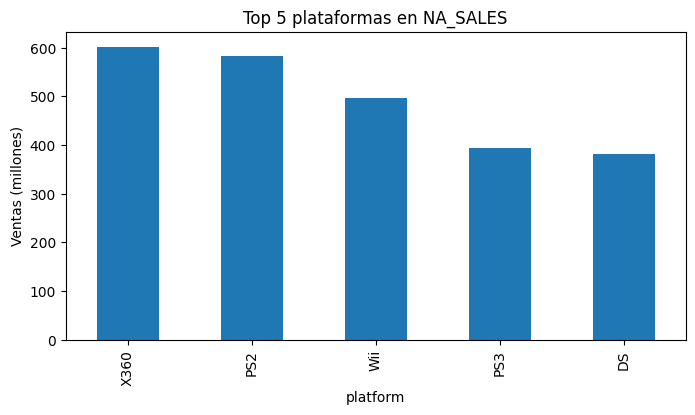


Top 5 plataformas en EU_SALES:
 platform
PS2     339.29
PS3     330.29
X360    270.76
Wii     262.21
PS      213.61
Name: eu_sales, dtype: float64


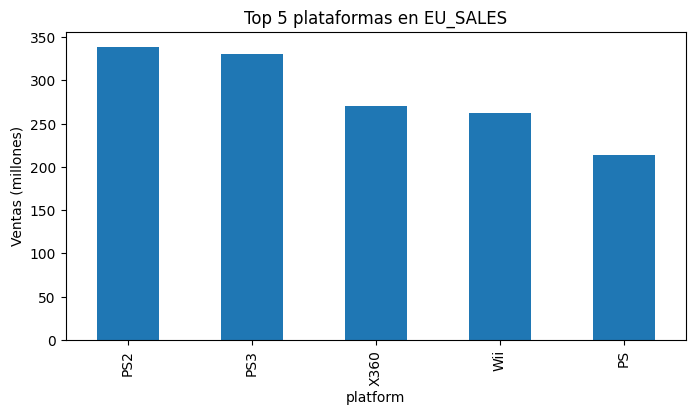


Top 5 plataformas en JP_SALES:
 platform
DS      175.57
PS      139.82
PS2     139.20
SNES    116.55
3DS     100.67
Name: jp_sales, dtype: float64


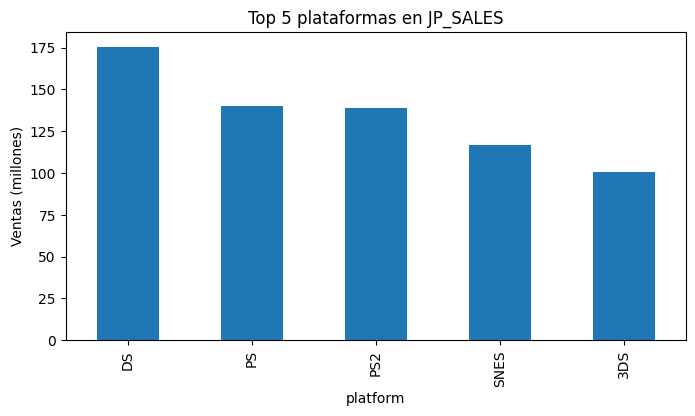

In [37]:
# Top 5 plataformas en NA, EU y JP
top_platforms_region = {}

for region in ["na_sales", "eu_sales", "jp_sales"]:
    top = df.groupby("platform")[region].sum().sort_values(ascending=False).head(5)
    top_platforms_region[region] = top
    print(f"\nTop 5 plataformas en {region.upper()}:\n", top)

    # Gráfico comparativo
    top.plot(kind="bar", figsize=(8,4), title=f"Top 5 plataformas en {region.upper()}")
    plt.ylabel("Ventas (millones)")
    plt.show()

In [38]:

# Se establecen las plataformas principales por región, en Norte America predomina X360 de Microsoft por un margen estrecho ante PS2 de Sony.
# En la Union Europea predominan la PS3 y PS2 ambas de Sony.
# En Japón como es de esperarse predomina una consola de Nintendo, la DS con un margen considerable por encima de la PS de Sony.



Top 5 géneros en NA_SALES:
 genre
Action      879.01
Sports      684.43
Shooter     592.24
Platform    445.50
Misc        407.27
Name: na_sales, dtype: float64


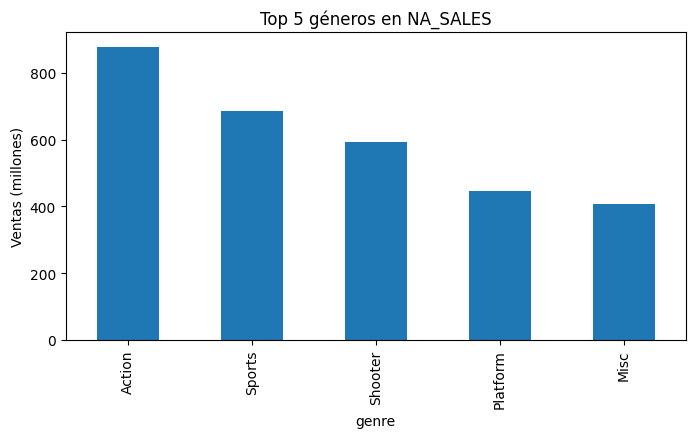


Top 5 géneros en EU_SALES:
 genre
Action     519.13
Sports     376.79
Shooter    317.34
Racing     236.51
Misc       212.74
Name: eu_sales, dtype: float64


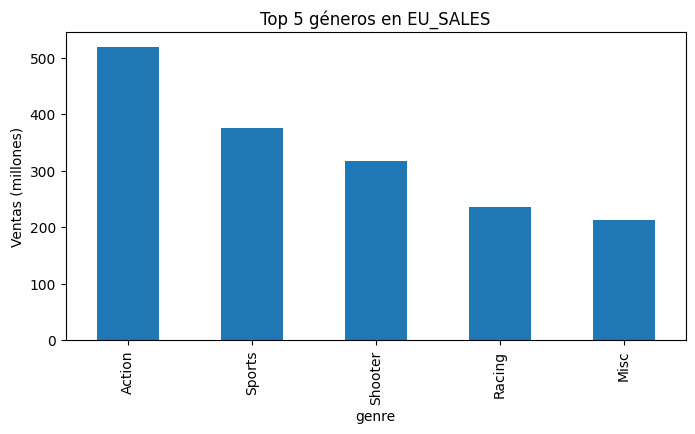


Top 5 géneros en JP_SALES:
 genre
Role-Playing    355.41
Action          161.43
Sports          135.54
Platform        130.83
Misc            108.11
Name: jp_sales, dtype: float64


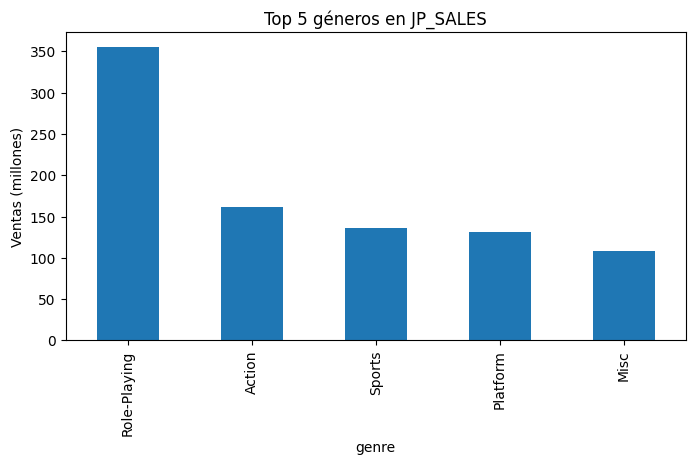

In [39]:
# Top 5 géneros en NA, EU y JP
top_genres_region = {}

for region in ["na_sales", "eu_sales", "jp_sales"]:
    top = df.groupby("genre")[region].sum().sort_values(ascending=False).head(5)
    top_genres_region[region] = top
    print(f"\nTop 5 géneros en {region.upper()}:\n", top)

    # Gráfico comparativo
    top.plot(kind="bar", figsize=(8,4), title=f"Top 5 géneros en {region.upper()}")
    plt.ylabel("Ventas (millones)")
    plt.show()


In [40]:

# En el caso de los generos, para Norte America y la Union Europea predominan los titulos de acción, deportes y los shooters en ese orden.
# Para Japón en cambio, el genero más popular es el de juegos de rol, por encima de los juegos de acción y deportes respectivamente.



Ventas por ESRB en NA_SALES:
 rating
E          1292.99
unknown    1242.46
T           759.75
M           748.48
E10+        353.32
K-A           2.56
EC            1.53
AO            1.26
RP            0.00
Name: na_sales, dtype: float64


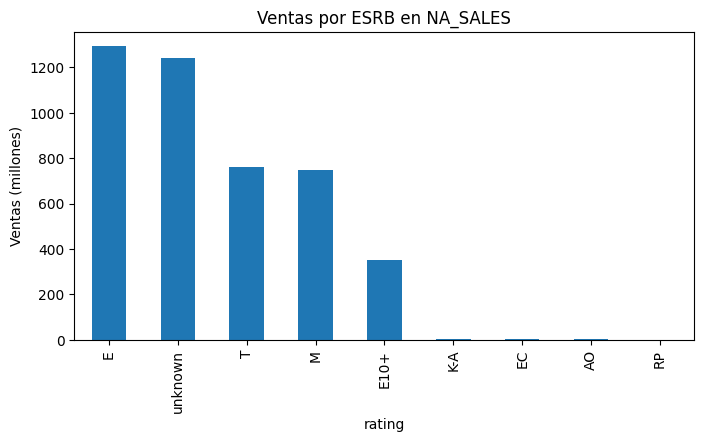


Ventas por ESRB en EU_SALES:
 rating
E          710.25
unknown    613.83
M          483.97
T          427.03
E10+       188.52
AO           0.61
K-A          0.27
EC           0.11
RP           0.08
Name: eu_sales, dtype: float64


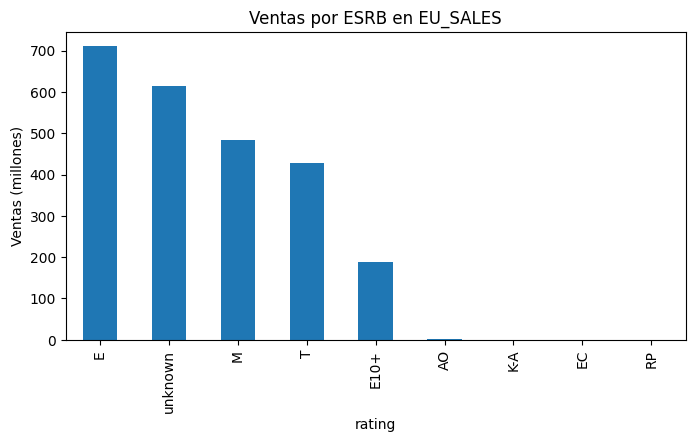


Ventas por ESRB en JP_SALES:
 rating
unknown    841.96
E          198.11
T          151.40
M           64.24
E10+        40.20
K-A          1.46
AO           0.00
EC           0.00
RP           0.00
Name: jp_sales, dtype: float64


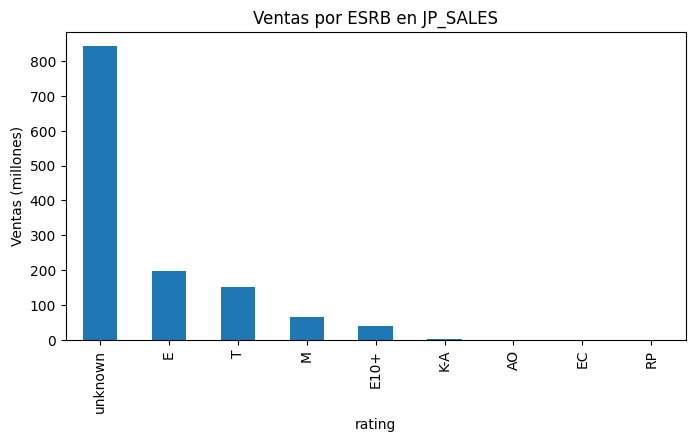

In [41]:
# Ventas por clasificación ESRB en cada región
for region in ["na_sales", "eu_sales", "jp_sales"]:
    esrb_sales = df.groupby("rating")[region].sum().sort_values(ascending=False)
    print(f"\nVentas por ESRB en {region.upper()}:\n", esrb_sales)

    esrb_sales.plot(kind="bar", figsize=(8,4), title=f"Ventas por ESRB en {region.upper()}")
    plt.ylabel("Ventas (millones)")
    plt.show()


In [42]:
# Sin tomar en consideración la clasificación 'unknown' que generamos para las clasificaciones faltantes, la clasificación E for Everyone es la que mayores ventas genera, por lo cual implica que la clasificación puede influir en la decisión de compra, esto a tomarse con precaución por la cantidad grande de 'unknown' en la base de datos.

In [43]:
# Filtrar calificaciones por plataforma
xone_scores = df[(df["platform"] == "XOne") & (df["user_score"].notnull())]["user_score"]
pc_scores   = df[(df["platform"] == "PC") & (df["user_score"].notnull())]["user_score"]

# Prueba t para muestras independientes
alpha = 0.05
t_stat, p_value = st.ttest_ind(xone_scores, pc_scores, equal_var=False)

print("Hipótesis 1: Xbox One vs PC")
print("t =", t_stat, ", p =", p_value)
if p_value < alpha:
    print("Rechazamos H₀ → Diferencia significativa entre Xbox One y PC")
else:
    print("No se puede rechazar H₀ → No hay diferencia significativa")

Hipótesis 1: Xbox One vs PC
t = -4.563286727694828 , p = 6.620192385517993e-06
Rechazamos H₀ → Diferencia significativa entre Xbox One y PC


In [44]:
# Filtrar calificaciones por género
action_scores = df[(df["genre"] == "Action") & (df["user_score"].notnull())]["user_score"]
sports_scores = df[(df["genre"] == "Sports") & (df["user_score"].notnull())]["user_score"]

# Prueba t para muestras independientes
t_stat, p_value = st.ttest_ind(action_scores, sports_scores, equal_var=False) 

print("\nHipótesis 2: Acción vs Deportes")
print("t =", t_stat, ", p =", p_value)
if p_value < alpha:
    print("Rechazamos H₀ → Diferencia significativa entre Acción y Deportes")
else:
    print("No se puede rechazar H₀ → No hay diferencia significativa")



Hipótesis 2: Acción vs Deportes
t = 1.6349093098145988 , p = 0.10213246174717988
No se puede rechazar H₀ → No hay diferencia significativa


In [45]:

# Utilizamos la prueba t para muestras independientes porque las varianzas pueden ser diferentes.
# Utilizamos nivel de significancia de 0.05


In [46]:
### Conclusión General

In [47]:
#Tras el análisis de los datos históricos de ventas de videojuegos, se identificaron patrones relevantes que permiten orientar decisiones estratégicas para campañas publicitarias y selección de proyectos:

#Preparación de los datos:
#Se ajustaron los tipos de datos de year_of_release y user_score, y se manejaron valores faltantes con imputaciones prudentes (NaN y categorías “unknown”) para no sesgar la información. El marcador TBD se trató como valor faltante.

#Evolución histórica:
#La industria alcanzó su punto más alto en lanzamientos entre 2008 y 2009, seguida de una caída marcada en 2011–2012. A partir de 2012 hasta 2016 se observa un periodo de estabilidad que constituye la base ideal para modelar tendencias hacia 2017.

#Plataformas:

#Plataformas con gran legado como PS2, PS3, Wii y X360 mostraron declive en el periodo 2012–2016.

#La nueva generación (PS4, XOne, 3DS, PSV) ganó participación con rapidez, lo que confirma ciclos de vida de alrededor de 10–11 años en consolas.

#Sony y Nintendo continúan siendo líderes globales, con Microsoft presente principalmente en Norteamérica.

#Ventas y distribución:
#Existen grandes diferencias en ventas entre títulos dentro de una misma plataforma, con valores atípicos que elevan promedios. Los géneros más rentables globalmente son Acción, Deportes, Shooter y RPG, aunque la preferencia varía por región:

#Norteamérica y Europa: predominan Acción, Deportes y Shooters.

#Japón: fuerte preferencia por RPG, seguido de Acción.

#Clasificaciones ESRB:
#Las clasificaciones parecen influir en la decisión de compra, en especial E (Everyone), aunque los valores desconocidos limitan la certeza de este hallazgo.

#Efecto de las reseñas:
#Las calificaciones de críticos muestran una correlación moderada con las ventas, mientras que las reseñas de usuarios prácticamente no impactan los resultados comerciales.

#Pruebas de hipótesis:

#Se confirmó una diferencia significativa entre las calificaciones de usuarios en Xbox One y PC.

#No se encontró diferencia estadísticamente significativa entre las calificaciones de Acción y Deportes